test026 construction diagnostics: min coverage=99.2%, median coverage=99.9%, varying days=100.0%
[2026-08-02 06:15:36] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-02 06:15:38] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-02 06:15:38] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-02 06:15:39] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-02 06:15:39] [info     ] ========== 数据检查 ==========
[2026-08-02 06:15:39] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'd

时段,IC
2024-01-15~2024-02-08,-0.0022
2024-09-24~2024-10-08,0.0443

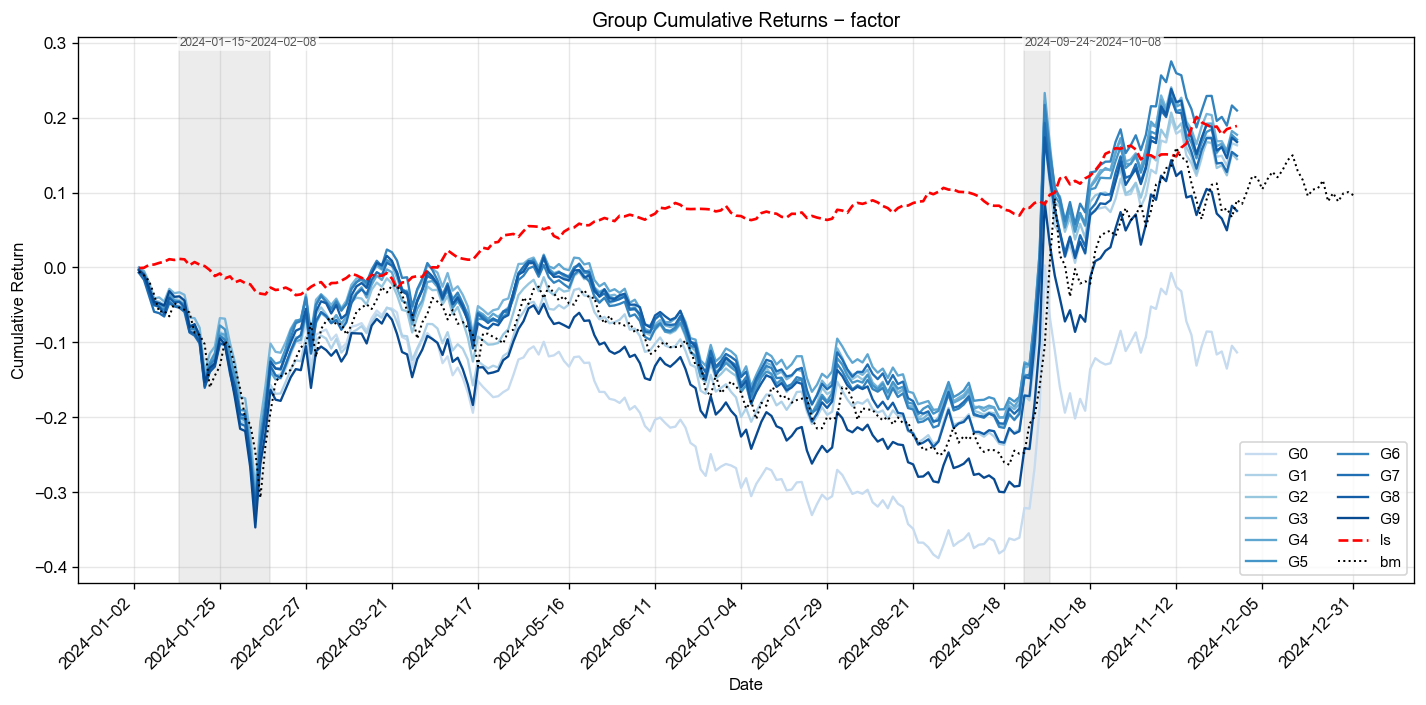
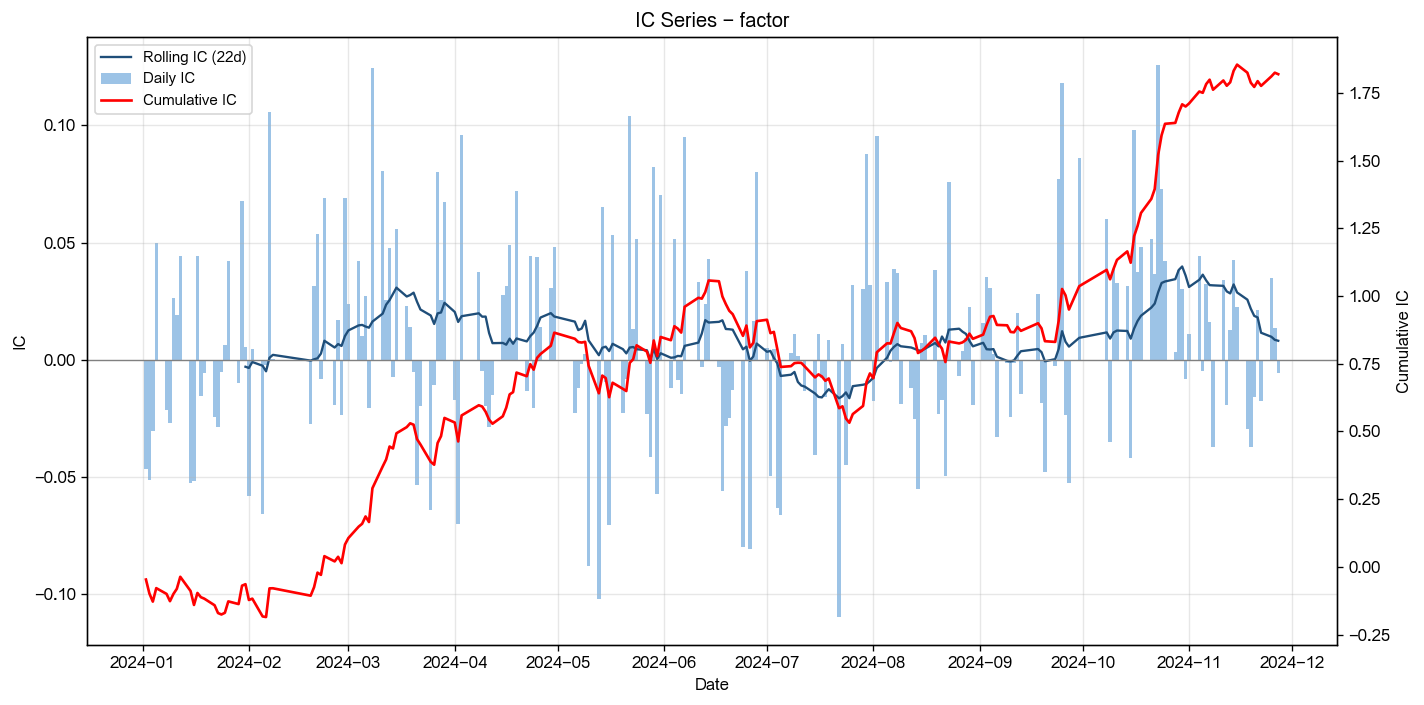
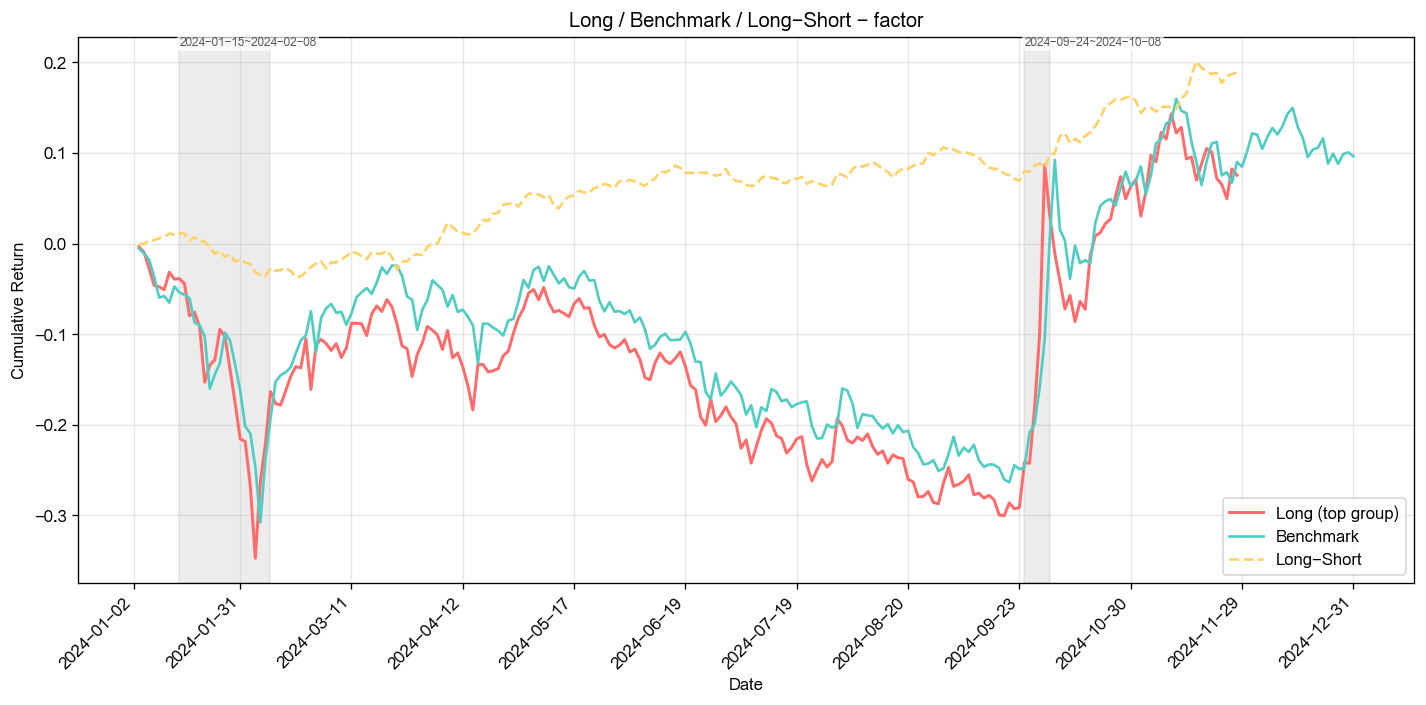
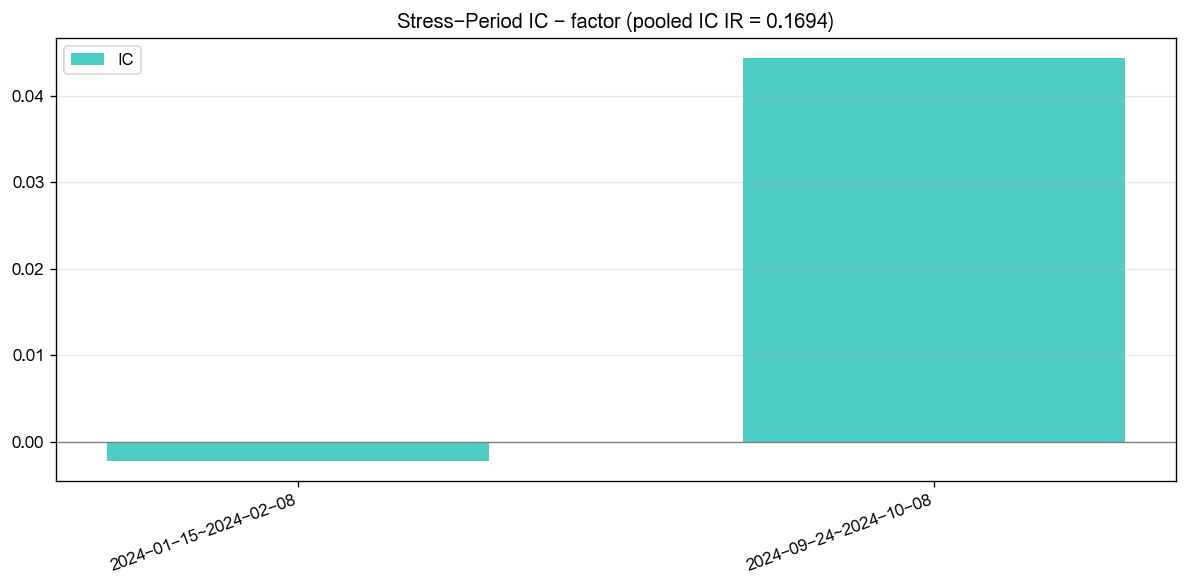
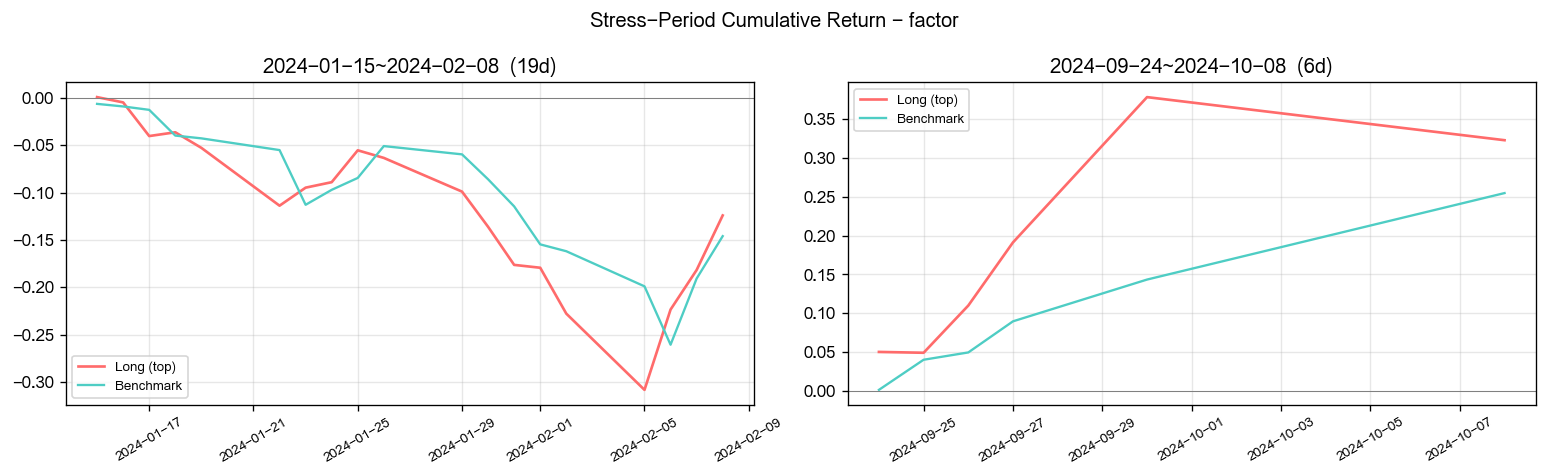

[2026-08-02 06:15:54] [info     ] ========== 因子池回归 ==========
[2026-08-02 06:15:54] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-02 06:15:54] [info     ] 获取收益率数据, 耗时: 0.6976 秒
[2026-08-02 06:15:55] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.2691 秒
[2026-08-02 06:15:55] [info     ] 统计 回归结果, 耗时: 0.0125 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9371,0.0446,0.0230,1.0000
2,amount,1.7078,0.0185,0.0108,0.9000
3,netflow_amount_rate_main,1.5418,0.0100,0.0065,1.0000
4,factor,1.5312,0.0046,0.0030,1.0000
5,netflow_amount_main,1.5178,0.0251,0.0165,1.0000
6,gross_profit_rate_ttm,1.5058,0.0069,0.0046,1.0000
7,net_profit_rate_ttm,1.4511,0.0040,0.0027,0.8000
8,pb,1.4243,0.0097,0.0068,1.0000
9,bias_20,1.4108,0.0292,0.0207,0.9000
10,cci_14,1.3905,0.0338,0.0243,1.0000

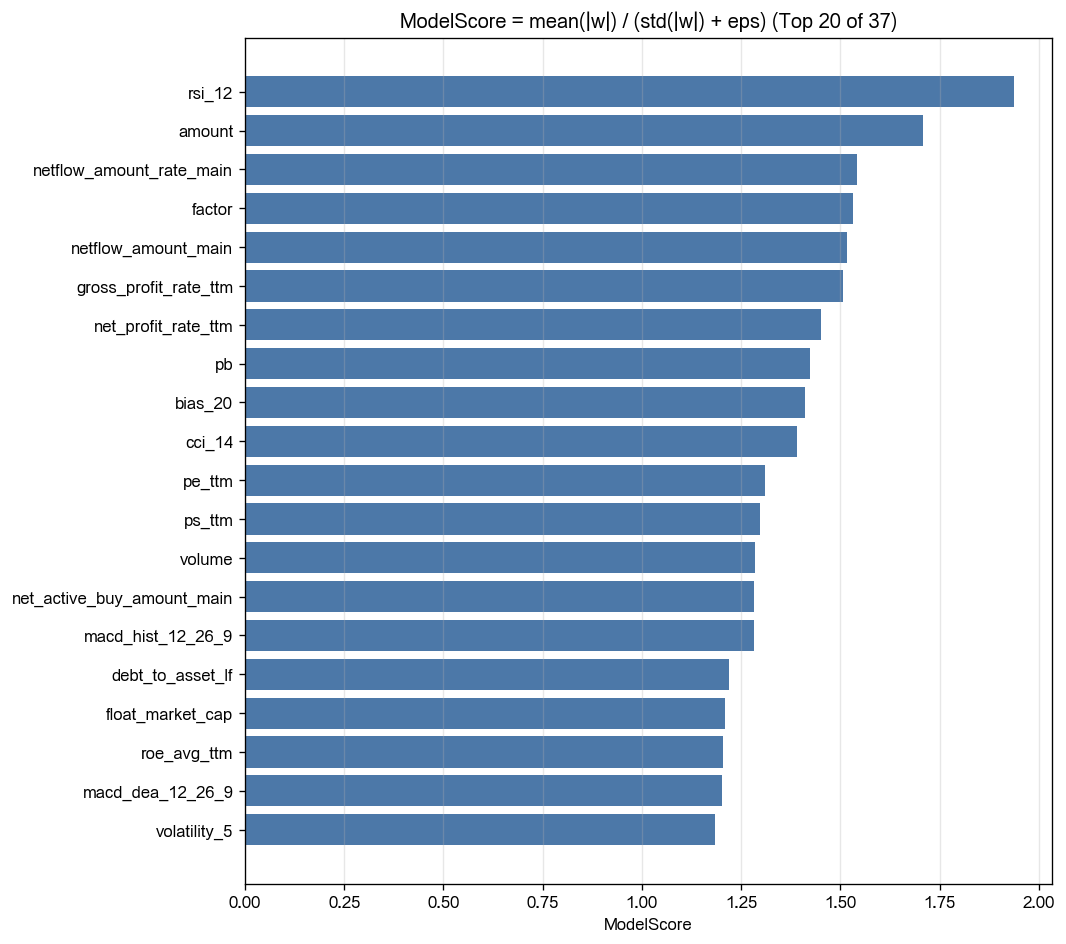
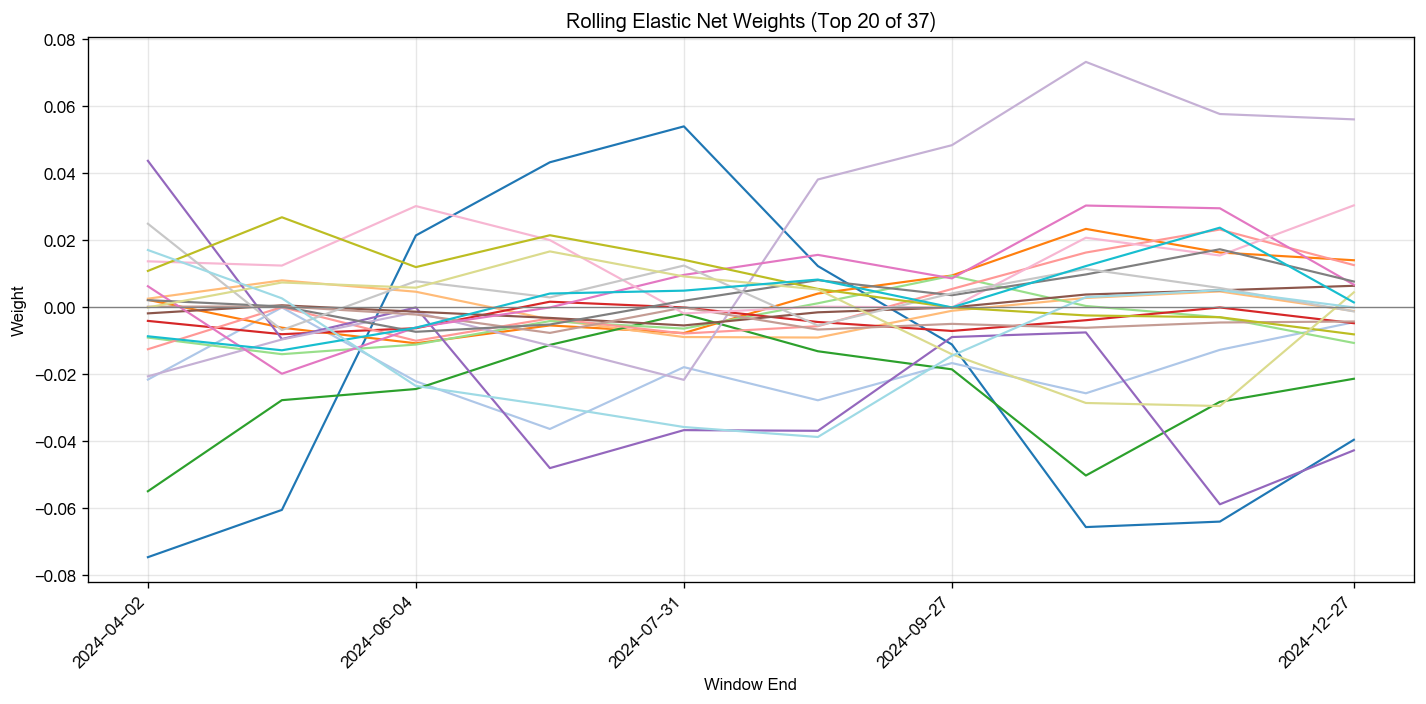
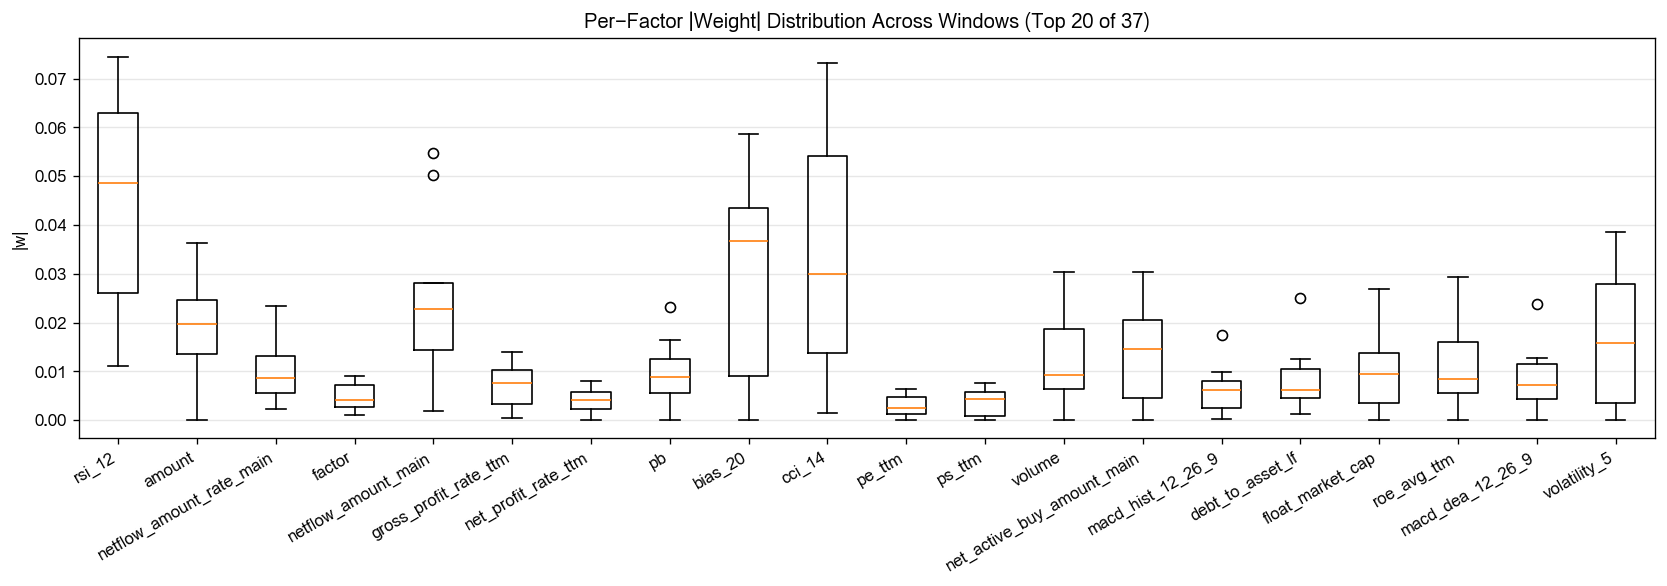
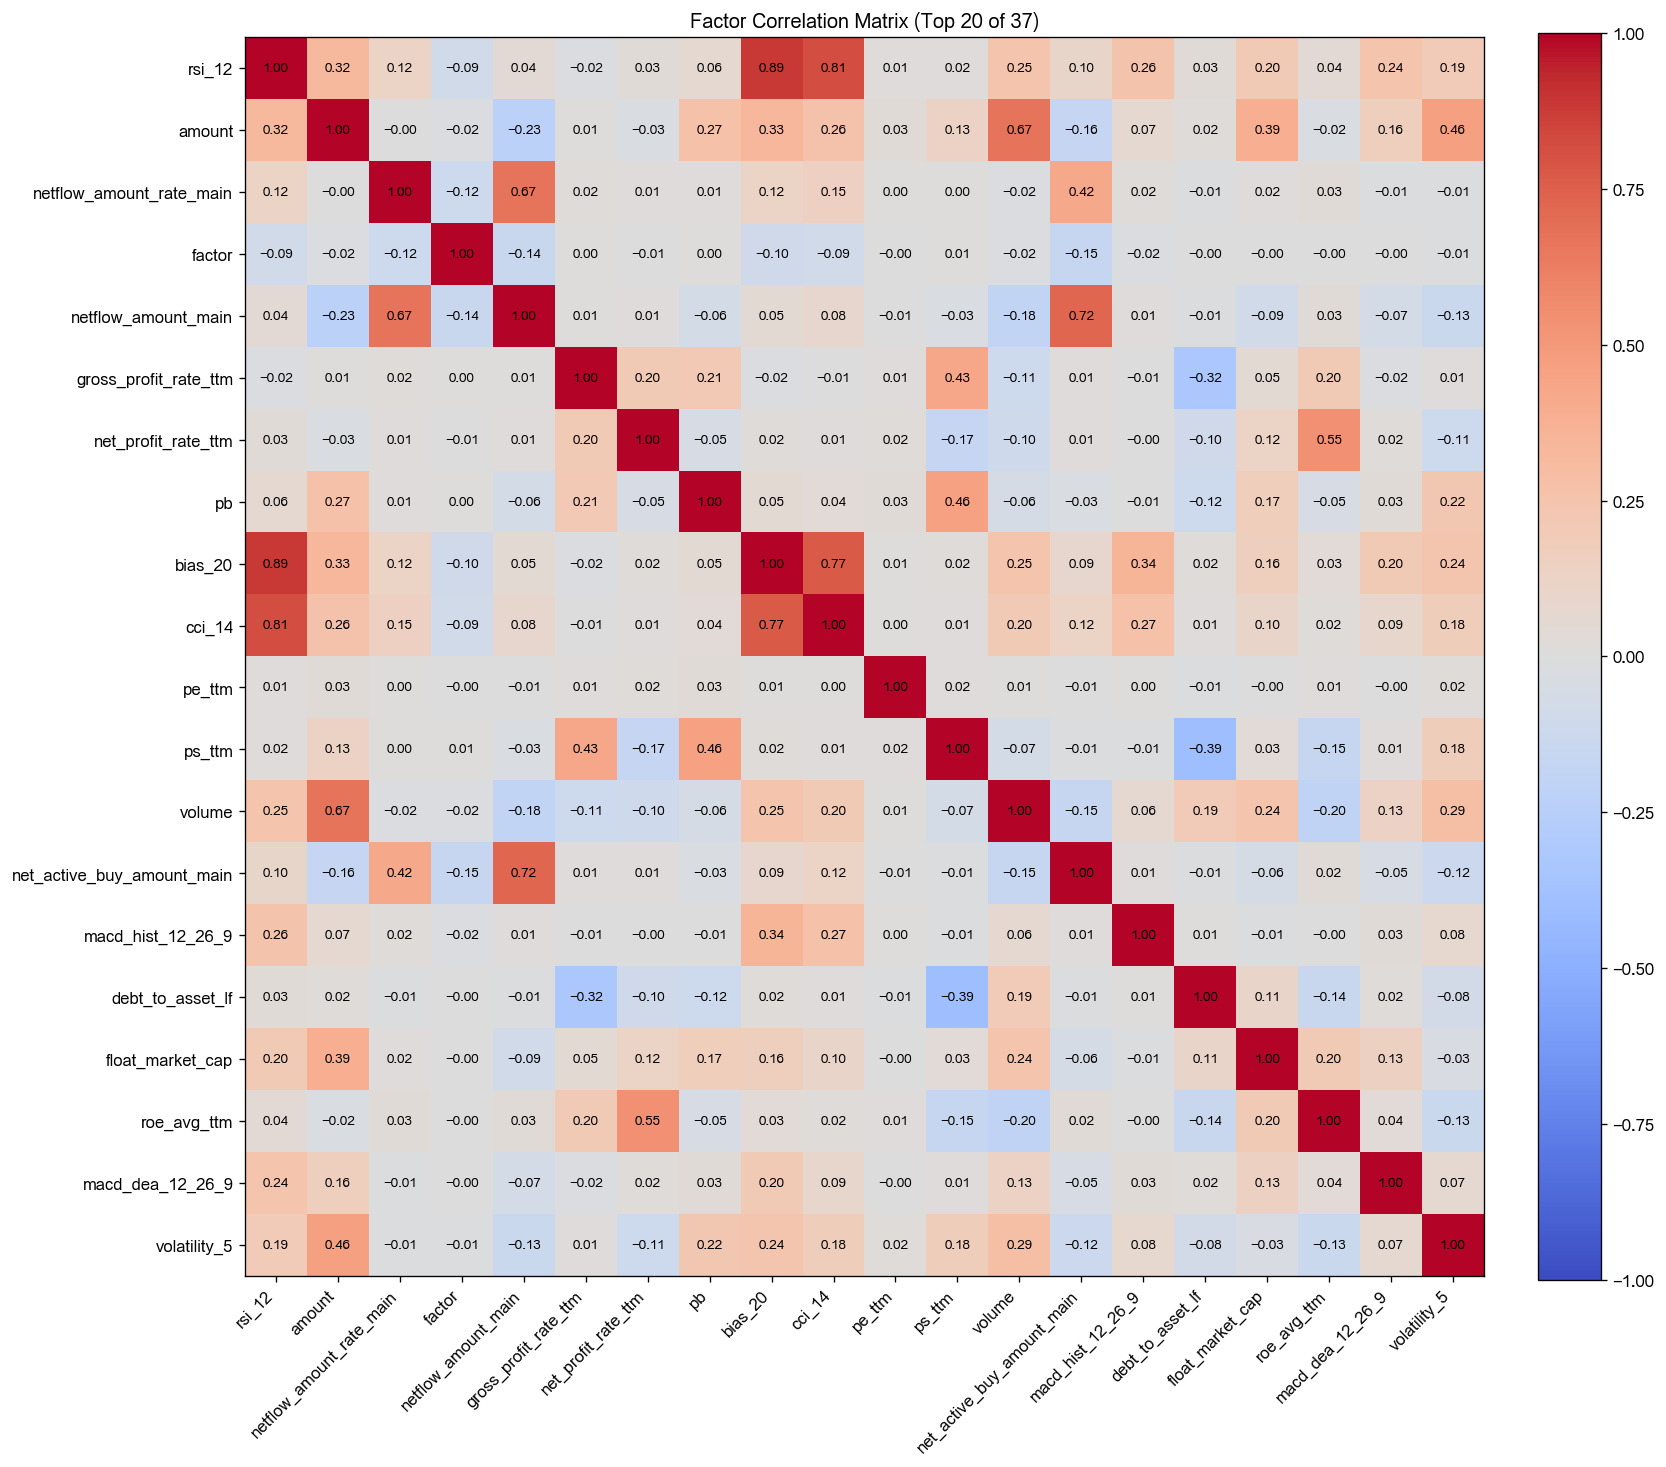

[2026-08-02 06:15:57] [warning  ] 返回的Outputs实例(size=35321131) 大于 64K, 将不会被缓存
[2026-08-02 06:15:57] [info     ] bigalpha_eval.v4 运行完成 [19.327s].


In [2]:
from __future__ import annotations
import re
import numpy as np
import pandas as pd
import dai
MIN_DAILY_COVERAGE = 0.6
MIN_VARYING_DAY_FRACTION = 0.8
EPS = 1e-12
FACTOR_SIGN = -1.0

def _safe_table_name(table_name: str) -> str:
    table_name = str(table_name)
    if not re.fullmatch('[A-Za-z_][A-Za-z0-9_.]*', table_name):
        raise ValueError(f'unsafe datasource table name: {table_name!r}')
    return table_name

def _query_daily_path(bar1m_table: str, start_date: str, end_date: str) -> pd.DataFrame:
    table = _safe_table_name(bar1m_table)
    start_ts = pd.Timestamp(start_date).strftime('%Y-%m-%d %H:%M:%S')
    end_ts = pd.Timestamp(end_date).strftime('%Y-%m-%d %H:%M:%S')
    sql = f"\n    WITH minute_raw AS (\n        SELECT\n            date,\n            date_trunc('day', date)::DATE AS trade_date,\n            instrument,\n            close,\n            lag(close, 1) OVER (\n                PARTITION BY instrument, date_trunc('day', date)\n                ORDER BY date\n            ) AS prev_minute_close\n        FROM {table}\n        WHERE date >= TIMESTAMP '{start_ts}'\n          AND date <= TIMESTAMP '{end_ts}'\n    ),\n    minute_returns AS (\n        SELECT\n            trade_date,\n            instrument,\n            CASE\n                WHEN close > 0 AND prev_minute_close > 0\n                THEN ln(close / prev_minute_close)\n                ELSE NULL\n            END AS minute_log_return\n        FROM minute_raw\n    )\n    SELECT\n        trade_date AS date,\n        instrument,\n        sum(minute_log_return) AS path_return,\n        sum(abs(minute_log_return)) AS path_total_variation,\n        count(minute_log_return) AS valid_bar_count\n    FROM minute_returns\n    GROUP BY 1, 2\n    ORDER BY 1, 2\n    "
    daily = dai.query(sql).df()
    if daily is None or daily.empty:
        raise RuntimeError(f'bar query returned no rows for {start_date}..{end_date}')
    daily = daily.copy()
    daily['date'] = pd.to_datetime(daily['date']).dt.normalize()
    for column in ['path_return', 'path_total_variation', 'valid_bar_count']:
        daily[column] = pd.to_numeric(daily[column], errors='coerce')
    daily = daily.sort_values(['date', 'instrument']).reset_index(drop=True)
    if daily.duplicated(['date', 'instrument']).any():
        raise RuntimeError('duplicate rows in daily path aggregation')
    return daily

def _centered_rank(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors='coerce')
    finite = numeric.notna() & np.isfinite(numeric)
    out = pd.Series(np.nan, index=values.index, dtype=float)
    count = int(finite.sum())
    if count == 0:
        return out
    if count == 1:
        out.loc[finite] = 0.0
        return out
    ranks = numeric.loc[finite].rank(method='average')
    out.loc[finite] = 2.0 * (ranks - 1.0) / (count - 1.0) - 1.0
    return out

def _construct_factor(daily: pd.DataFrame) -> pd.DataFrame:
    frame = daily.copy()
    path_return = pd.to_numeric(frame['path_return'], errors='coerce')
    total_variation = pd.to_numeric(frame['path_total_variation'], errors='coerce')
    efficiency = pd.Series(np.nan, index=frame.index, dtype=float)
    valid = path_return.notna() & np.isfinite(path_return) & total_variation.notna() & np.isfinite(total_variation) & (total_variation >= 0.0)
    moving = valid & (total_variation > EPS)
    efficiency.loc[valid & ~moving] = 0.0
    efficiency.loc[moving] = (path_return.loc[moving].abs() / total_variation.loc[moving]).clip(0.0, 1.0)
    frame['path_efficiency'] = efficiency
    frame['direction_rank'] = frame.groupby('date', group_keys=False)['path_return'].transform(_centered_rank)
    frame['efficiency_rank'] = frame.groupby('date', group_keys=False)['path_efficiency'].transform(_centered_rank)
    frame['raw_factor'] = frame['direction_rank'] * frame['efficiency_rank']
    frame['factor'] = FACTOR_SIGN * frame.groupby('date', group_keys=False)['raw_factor'].transform(_centered_rank)
    return frame

def _align_and_validate_output(result: pd.DataFrame, start_date: str, end_date: str) -> pd.DataFrame:
    required = ['date', 'instrument', 'factor']
    result = result[required].copy()
    result['date'] = pd.to_datetime(result['date']).dt.normalize()
    result['factor'] = pd.to_numeric(result['factor'], errors='coerce')
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=['factor'])
    if result.duplicated(['date', 'instrument']).any():
        raise RuntimeError('duplicate date/instrument rows in factor output')
    universe = dai.query('SELECT date, instrument FROM bigalpha_2026_instruments', filters={'date': [start_date, end_date]}).df()
    if universe is None or universe.empty:
        raise RuntimeError('instrument-universe query returned no rows')
    universe = universe[['date', 'instrument']].copy()
    universe['date'] = pd.to_datetime(universe['date']).dt.normalize()
    universe = universe.drop_duplicates(['date', 'instrument'])
    out = result.merge(universe, on=['date', 'instrument'], how='inner', validate='one_to_one')
    if out.empty:
        raise RuntimeError('official-universe alignment returned no rows')
    if not np.isfinite(out['factor'].to_numpy(dtype=float)).all():
        raise RuntimeError('non-finite factor values remain after alignment')
    if out['date'].nunique() != universe['date'].nunique():
        raise RuntimeError('factor output is missing one or more trading days')
    daily_output_count = out.groupby('date')['instrument'].nunique()
    daily_universe_count = universe.groupby('date')['instrument'].nunique()
    coverage = daily_output_count.div(daily_universe_count).fillna(0.0)
    if float(coverage.min()) < MIN_DAILY_COVERAGE:
        raise RuntimeError(f'minimum daily factor coverage is only {coverage.min():.1%}')
    varying = out.groupby('date')['factor'].std().fillna(0.0).gt(EPS)
    if float(varying.mean()) < MIN_VARYING_DAY_FRACTION:
        raise RuntimeError(f'factor is cross-sectionally constant on too many days: {varying.mean():.1%} varying')
    return out[['date', 'instrument', 'factor']].sort_values(['date', 'instrument']).reset_index(drop=True)

def main(datasources, start_date, end_date):
    daily = _query_daily_path(datasources['bar1m'], start_date, end_date)
    constructed = _construct_factor(daily)
    result = constructed[['date', 'instrument', 'factor']]
    return _align_and_validate_output(result, start_date, end_date)
